# Fraud Detection Machine Learning Notebook

In this notebook, I will build the machine learning part of my fraud detection project using the final features created from my earlier ETL and feature engineering steps.

The main goal is to train models that can predict whether a transaction is fraudulent or legitimate, while also handling the fact that fraud cases are much fewer than normal transactions.

I will start by loading and checking the `fraud_features.csv` file. This includes reviewing the columns, missing values, data types, and the fraud imbalance in the dataset. Then, I will prepare the data by removing columns that could cause data leakage, encoding categorical columns, and splitting the data chronologically so the model is trained on earlier transactions and tested on later transactions.

After that, I will train and compare different models, starting with Logistic Regression as a baseline, then Random Forest, and finally XGBoost. Since this is an imbalanced fraud problem, I will focus more on PR-AUC, recall, precision, F2-score, and confusion matrices instead of relying only on accuracy.

I will also tune the prediction threshold because the default `0.50` cutoff is not always the best choice for fraud detection. The goal is to catch more fraud cases while still keeping false alerts reasonable.

Once the best model is selected, I will explain its predictions using SHAP so I can understand which features are driving the fraud risk. This makes the model easier to interpret and easier to explain in the final dashboard.

At the end, I will save the best model, metadata, prediction outputs, and Power BI-ready files. These outputs can then be connected back to SQL Server and Power BI to support the final fraud monitoring dashboard.



In [1]:
# ─────────────────────────────────────────────────────────────
# Imports & Project Configuration
# ─────────────────────────────────────────────────────────────


import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


# ─────────────────────────────────────────────────────────────
# Notebook display settings
# ─────────────────────────────────────────────────────────────

# Hide warning messages to keep the notebook output cleaner.
warnings.filterwarnings('ignore')

# Show decimal numbers in a cleaner format instead of scientific notation.
pd.set_option('display.float_format', '{:.4f}'.format)


# ─────────────────────────────────────────────────────────────
# Scikit-learn imports
# ─────────────────────────────────────────────────────────────
# Scikit-learn is the main machine learning library used here. It gives us models, preprocessing tools, pipelines, and evaluation metrics.

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    PrecisionRecallDisplay,
    precision_recall_curve,
    fbeta_score,
    precision_score,
    recall_score
)


# ─────────────────────────────────────────────────────────────
# Imbalanced-learn imports
# ─────────────────────────────────────────────────────────────
# Fraud datasets are usually highly imbalanced because fraud cases are rare.
# SMOTE helps create synthetic fraud examples for the training data only.


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# ─────────────────────────────────────────────────────────────
# XGBoost import
# ─────────────────────────────────────────────────────────────
# XGBoost is a strong gradient boosting model.
# It usually performs well on structured/tabular datasets like transactions.

import xgboost as xgb


# ─────────────────────────────────────────────────────────────
# SHAP import
# ─────────────────────────────────────────────────────────────
# SHAP helps explain model predictions.
# Later, we can use it to understand which features pushed a transaction toward fraud or legitimate.

import shap


# ─────────────────────────────────────────────────────────────
# Project paths
# ─────────────────────────────────────────────────────────────


ROOT = Path('..')

# Main ML input file created from the feature engineering phase.
DATA_PATH = ROOT / 'data' / 'processed' / 'fraud_features.csv'

# Folder for saved trained models, encoders, and related ML artifacts.
MODELS_DIR = Path('models')

# Folder for charts, evaluation tables, and exported reports.
REPORTS_DIR = Path('reports')

# Create the folders if they do not already exist.

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)


# ─────────────────────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────────────────────
# Setting a seed helps make results more consistent between runs.
# This affects random operations in NumPy and will also be reused later in ML models such as Logistic Regression, Random Forest, SMOTE, and XGBoost.

SEED = 42
np.random.seed(SEED)


# ─────────────────────────────────────────────────────────────
# Plot style
# ─────────────────────────────────────────────────────────────
# Use a dark theme because the final dashboard/report style is dark.


plt.style.use('dark_background')

PALETTE = {
    'legit': '#4B9CD3',   # blue for legitimate transactions
    'fraud': '#E05C5C',   # red for fraud transactions
    'accent': '#A67BDB'   # purple accent color for highlights
}


# ─────────────────────────────────────────────────────────────
# Setup confirmation
# ─────────────────────────────────────────────────────────────
# Print library versions so we know the environment used to run the notebook.
# This is useful later if results need to be reproduced or debugged.

print('All imports successful')
print(f'   XGBoost  : {xgb.__version__}')
print(f'   SHAP     : {shap.__version__}')

All imports successful
   XGBoost  : 3.2.0
   SHAP     : 0.49.1


In [2]:
# ─────────────────────────────────────────────────────────────
# Load and Audit the Feature Dataset
# ─────────────────────────────────────────────────────────────
# In this cell, I load the final feature-engineered dataset that was created earlier in the project.
#
# Before training any machine learning model, I want to understand the dataset properly: like how many rows it has, how many columns it has, the date range, memory size, column types, sample values, and whether there are any missing values.

# Load the final fraud feature dataset.
# parse_dates makes sure the transaction timestamp is treated as a real datetime column instead of plain text.
df = pd.read_csv(DATA_PATH, parse_dates=['trans_date_trans_time'])

# Sort the dataset by transaction time.
# This is important for fraud detection because later we want to split the data chronologically: older transactions for training and newer transactions for testing.
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)


# ─────────────────────────────────────────────────────────────
# Basic dataset overview
# ─────────────────────────────────────────────────────────────

print('─── Shape & Date Range ──────────────────────')


print(f'  Rows         : {len(df):,}')


print(f'  Columns      : {df.shape[1]}')

# Show the first and last transaction dates:  This helps confirm that the dataset covers the expected time period.
print(
    f'  Date range   : '
    f'{df["trans_date_trans_time"].min().date()} → '
    f'{df["trans_date_trans_time"].max().date()}'
)

# Estimate the memory size of the DataFrame.
# This is useful because the dataset is large, so I need to be aware of memory usage before running models like Random Forest, XGBoost, and SHAP.
print(f'  Memory       : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')


# ─────────────────────────────────────────────────────────────
# Column-by-column audit
# ─────────────────────────────────────────────────────────────

print('\n─── All Columns ─────────────────────────────')

# Loop through every column and print:
#   - column name
#   - data type
#   - one sample value
#   - number of nulls if any exist
#
for col in df.columns:
    n_null = df[col].isnull().sum()

    # Only show a warning message when the column actually has missing values.
    null_str = f'   {n_null:,} nulls' if n_null > 0 else ''

    print(
        f'  {col:<30} '
        f'{str(df[col].dtype):<15} '
        f'sample: {df[col].iloc[0]}'
        f'{null_str}'
    )


# ─────────────────────────────────────────────────────────────
# Missing value summary
# ─────────────────────────────────────────────────────────────

print('\n─── Nulls Summary ───────────────────────────')

null_report = df.isnull().sum()

null_report = null_report[null_report > 0]

# If there are no missing values, print a clean confirmation. Otherwise, display the columns that need attention.
if len(null_report) == 0:
    print('  None ')
else:
    print(null_report)

─── Shape & Date Range ──────────────────────
  Rows         : 1,296,675
  Columns      : 30
  Date range   : 2019-01-01 → 2020-06-21
  Memory       : 1573.1 MB

─── All Columns ─────────────────────────────
  transaction_id                 int64           sample: 0
  trans_date_trans_time          datetime64[ns]  sample: 2019-01-01 00:00:18
  category                       object          sample: misc_net
  gender                         object          sample: F
  trans_num                      object          sample: 0b242abb623afc578575680df30655b9
  is_fraud                       int64           sample: 0
  province_code                  object          sample: ON
  city_tier                      object          sample: Small Town
  city_ca                        object          sample: North Judithbury
  postal_code                    object          sample: P7H2N1
  lat                            float64         sample: 49.498838
  long                           float64         

The dataset was loaded successfully from `fraud_features.csv`.

The file contains **1,296,675 transactions** and **30 columns**, covering transactions from **January 1, 2019 to June 21, 2020**. This confirms that the dataset has a clear time range, which is important because I will later split the data chronologically: older transactions for training and newer transactions for testing.

The memory usage is around **1.57 GB**, so this is a large dataset. Because of that, I need to be careful when training heavier models such as Random Forest, XGBoost, and SHAP explanations.

I also checked every column, including its data type, one sample value, and whether it has missing values. The dataset includes transaction details, location features, amount-based features, time-based features, customer/merchant-related fields, and the target column `is_fraud`.

The null check showed that there are **no missing values**, which means the dataset is clean enough to move forward to the next step.

VIP Note:  is that some columns such as `fraud_type`, `fraud_score`, and `risk_tier` were created during feature engineering. These columns need to be reviewed carefully before modeling because some of them may cause data leakage if they are directly derived from the fraud label.

─── Class Distribution ──────────────────────
  Legitimate :  1,289,169  (99.421%)
  Fraud      :      7,506  (0.579%)
  Ratio      : 1 fraud per 171 legitimate transactions

   Strategy decisions:
     - Use SMOTE on training fold ONLY (never on test)
     - Primary metric  → PR-AUC (not accuracy/ROC-AUC)
     - Secondary metric → F2-Score (recall weighted 2×)
     - Threshold tuning after training (default 0.5 is wrong here)


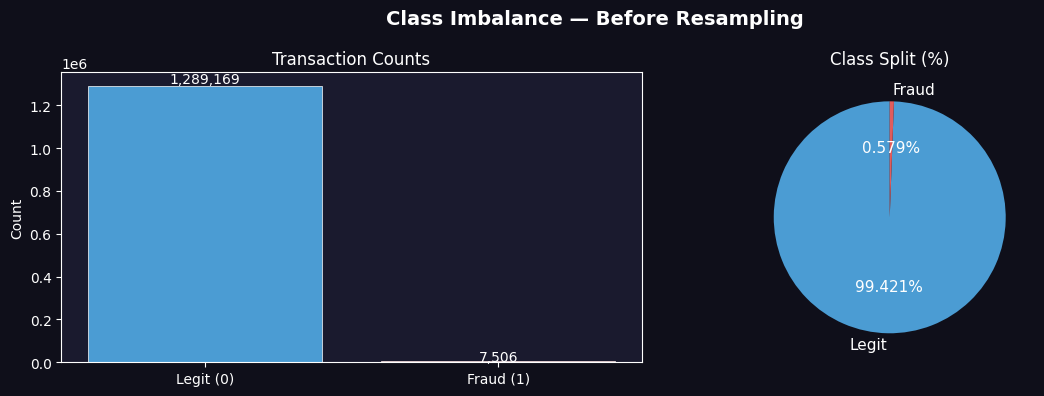

In [4]:
# ─────────────────────────────────────────────────────────────
#Class Imbalance Analysis
# ─────────────────────────────────────────────────────────────
# In this cell, I check how imbalanced the target variable is.
# This is a very important step in fraud detection because fraud cases are usually rare compared to legitimate transactions.
#
# The imbalance level affects almost everything later:
#   - whether I should use SMOTE
#   - which evaluation metric matters most
#   - whether the default threshold of 0.50 is appropriate
#
# so, this cell helps define the modeling strategy.

# Count how many transactions belong to each class in the target column.

fraud_counts = df['is_fraud'].value_counts()

# Calculate the percentage of fraud transactions in the full dataset.
fraud_rate = df['is_fraud'].mean() * 100

# Calculate the imbalance ratio:
# how many legitimate transactions exist for every 1 fraud transaction.
imbalance_ratio = int(fraud_counts[0] / fraud_counts[1])


# ─────────────────────────────────────────────────────────────
# Print class distribution summary
# ─────────────────────────────────────────────────────────────
print('─── Class Distribution ──────────────────────')
print(f'  Legitimate : {fraud_counts[0]:>10,}  ({100 - fraud_rate:.3f}%)')
print(f'  Fraud      : {fraud_counts[1]:>10,}  ({fraud_rate:.3f}%)')
print(f'  Ratio      : 1 fraud per {imbalance_ratio:,} legitimate transactions')
print()

# Based on this distribution, print the main strategy decisions
# that will guide the next ML steps.
print('   Strategy decisions:')
print('     - Use SMOTE on training fold ONLY (never on test)')
print('     - Primary metric  → PR-AUC (not accuracy/ROC-AUC)')
print('     - Secondary metric → F2-Score (recall weighted 2×)')
print('     - Threshold tuning after training (default 0.5 is wrong here)')


# ─────────────────────────────────────────────────────────────
# Visualize the imbalance
# ─────────────────────────────────────────────────────────────
# Create a figure with two side-by-side plots:
#   1) bar chart for raw counts
#   2) pie chart for percentage split
fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor='#0f0f1a')

# Main title for the full figure
fig.suptitle(
    'Class Imbalance — Before Resampling',
    fontsize=14,
    fontweight='bold',
    color='white'
)


# ─────────────────────────────────────────────────────────────
# Left plot: bar chart
# ─────────────────────────────────────────────────────────────
bars = axes[0].bar(
    ['Legit (0)', 'Fraud (1)'],
    fraud_counts.values,
    color=[PALETTE['legit'], PALETTE['fraud']],
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_title('Transaction Counts', color='white')
axes[0].set_ylabel('Count', color='white')
axes[0].tick_params(colors='white')
axes[0].set_facecolor('#1a1a2e')

# Add the exact count value above each bar
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{int(val):,}',
        ha='center',
        color='white',
        fontsize=10
    )


# ─────────────────────────────────────────────────────────────
# Right plot: pie chart
# ─────────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    fraud_counts.values,
    labels=['Legit', 'Fraud'],
    autopct='%1.3f%%',
    colors=[PALETTE['legit'], PALETTE['fraud']],
    startangle=90,
    textprops={'color': 'white', 'fontsize': 11}
)

# Make the percentage labels inside the pie chart white as well
for at in autotexts:
    at.set_color('white')

axes[1].set_title('Class Split (%)', color='white')
axes[1].set_facecolor('#1a1a2e')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────
plt.tight_layout()

# Save the chart into the reports folder so I can reuse it later
# in documentation, GitHub, or Power BI project notes.
plt.savefig(
    REPORTS_DIR / 'class_imbalance.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

The target column `is_fraud` is highly imbalanced. Out of 1,296,675 total transactions, only 7,506 transactions are fraud, which represents about 0.579% of the dataset. This means there is approximately 1 fraud transaction for every 171 legitimate transactions.

Because of this imbalance, accuracy is not a reliable metric for this project. A model could achieve very high accuracy by predicting almost every transaction as legitimate, but it would still fail to catch fraud cases.

For this reason, I will focus on PR-AUC as the main evaluation metric because it is more useful for imbalanced classification problems. I will also use F2-score as a secondary metric because fraud detection should give more weight to recall, meaning the model should try to catch as many fraud cases as possible.

This imbalance also explains why I will apply SMOTE only to the training data and keep the test data untouched. The test set should stay realistic so the final evaluation reflects how the model would perform on real future transactions.

Finally, I will tune the prediction threshold after training because the default 0.50 threshold is usually not the best choice for fraud detection.

In [5]:
# ─────────────────────────────────────────────────────────────
# Feature Selection
# ─────────────────────────────────────────────────────────────
# In this cell, I choose which columns should be used as model features.
#
# The model should only learn from useful business and transaction signals.
# It should not learn from IDs, personal information, raw timestamps, or columns that were created using the fraud label.
#
# This step is important because bad feature selection can make the model look better than it really is, especially if data leakage exists.

# Target column: this is the value the model will try to predict.
# is_fraud = 0 means legitimate transaction
# is_fraud = 1 means fraudulent transaction
TARGET = 'is_fraud'


# ─────────────────────────────────────────────────────────────
# Columns that should not be used as model features
# ─────────────────────────────────────────────────────────────



DROP_CANDIDATES = [
    # Raw datetime column.
    # I already created separate time features from it, such as:
    # transaction_hour, transaction_day, transaction_month, and time_of_day.
    'trans_date_trans_time',

    # Unique transaction identifier.
    # It identifies a row, but it does not teach the model a general fraud pattern.
    'transaction_id',

    # Unique transaction number.
    # This is also an ID, so the model should not learn from it.
    'trans_num',

    # Masked card number.
    # Even though it is masked, it is still an identifier, not a behavioral feature.
    'cc_num_masked',

    # Very specific location fields.
    # I keep more general location features like province_code and city_tier instead.
    'city_ca',
    'postal_code',

    # Raw coordinates.
    # I already have dist_km, which is a cleaner distance feature.
    'lat',
    'long',
    'merch_lat',
    'merch_long',

    # Specific merchant name.
    # I keep category instead because it is more general and easier to explain.
    'merchant_ca',

    # Columns created from fraud logic.
    # These can leak information from the target or make the model look too strong.
    'fraud_type',
    'fraud_score',
    'risk_tier',
]


# ─────────────────────────────────────────────────────────────
# Apply the drop list safely
# ─────────────────────────────────────────────────────────────
# Only drop columns that actually exist in the dataframe.
drop_cols = [c for c in DROP_CANDIDATES if c in df.columns]

# The final feature list includes every column except:
#   - the dropped columns
#   - the target column is_fraud
feature_cols = [c for c in df.columns if c not in drop_cols + [TARGET]]


# ─────────────────────────────────────────────────────────────
# Print selected features
# ─────────────────────────────────────────────────────────────
print(f'Dropped   : {len(drop_cols)} columns → {drop_cols}')
print(f'\nFeatures  : {len(feature_cols)} columns')
print()

# Display the remaining feature columns and their data types.
# This helps me confirm what will go into the model before encoding and training.
for col in feature_cols:
    print(f'  {col:<30} {str(df[col].dtype)}')

Dropped   : 14 columns → ['trans_date_trans_time', 'transaction_id', 'trans_num', 'cc_num_masked', 'city_ca', 'postal_code', 'lat', 'long', 'merch_lat', 'merch_long', 'merchant_ca', 'fraud_type', 'fraud_score', 'risk_tier']

Features  : 15 columns

  category                       object
  gender                         object
  province_code                  object
  city_tier                      object
  dist_km                        float64
  amount_cad                     float64
  transaction_hour               int64
  transaction_day                object
  transaction_month              object
  is_weekend                     int64
  time_of_day                    object
  is_amount_outlier              int64
  amount_bin                     object
  age_group                      object
  amount_zscore                  float64


In this step, I selected the final input features that will be used by the machine learning models.

I dropped 14 columns that were not suitable for training. These included identifiers such as `transaction_id`, `trans_num`, and `cc_num_masked`, raw timestamp and coordinate columns, highly specific location or merchant fields, and fraud-derived columns such as `fraud_type`, `fraud_score`, and `risk_tier`.

This step is important because the model should learn from real transaction behavior, not from IDs or columns that already contain fraud-related logic. Keeping those columns could cause data leakage or make the model look unrealistically strong.

After feature selection, 15 columns remained. These features describe the transaction amount, distance, time, customer/location grouping, category, and amount behavior. This gives the model a cleaner and more explainable set of inputs for fraud detection.

In [6]:
# ─────────────────────────────────────────────────────────────
# Encode Categorical Features
# ─────────────────────────────────────────────────────────────
# In this cell, I prepare the final ML dataframe.
#
#
#
# I use LabelEncoder here to convert each category into an integer code.
# For example:
#   gender: F, M  →  0, 1
#   time_of_day: Late Night, Morning, Afternoon  →  numeric labels
#
# I also save all encoders so I can reuse them later when decoding results or applying the same transformation to new data.

# Keep only the selected feature columns and the target column.
# This creates a clean modeling dataframe.
df_ml = df[feature_cols + [TARGET]].copy()


# ─────────────────────────────────────────────────────────────
# Identify categorical columns
# ─────────────────────────────────────────────────────────────
# Select all columns with text/category values.
# These columns need encoding before model training.
cat_cols = df_ml.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Encoding {len(cat_cols)} categorical columns:')


# ─────────────────────────────────────────────────────────────
# Encode each categorical column
# ─────────────────────────────────────────────────────────────
# le_registry will store one LabelEncoder per column.
# This is useful because each column has its own set of categories.
le_registry = {}

for col in cat_cols:
    # Create a new encoder for the current column.
    le = LabelEncoder()

    # Convert the column to string first to avoid issues with mixed types.
    # Then fit the encoder and replace the original text values with numbers.
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

    # Save the fitted encoder in the registry using the column name as the key.
    le_registry[col] = le

    # Store the category names so I can quickly review what was encoded.
    classes = list(le.classes_)

    # If a column has many categories, show only the first 5 to keep output clean.
    suffix = '...' if len(classes) > 5 else ''

    print(
        f'  {col:<25} → {len(classes)} classes: '
        f'{classes[:5]}{suffix}'
    )


# ─────────────────────────────────────────────────────────────
# Save encoders
# ─────────────────────────────────────────────────────────────
# Saving the encoders is important because the same category-to-number
# mapping should be reused later when scoring new data.
joblib.dump(le_registry, MODELS_DIR / 'label_encoders.pkl')

print(f'\n Encoders saved → {MODELS_DIR / "label_encoders.pkl"}')
print(f'   Final shape: {df_ml.shape}')

Encoding 9 categorical columns:
  category                  → 14 classes: ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos']...
  gender                    → 2 classes: ['F', 'M']
  province_code             → 8 classes: ['AB', 'BC', 'MB', 'NB', 'NS']...
  city_tier                 → 4 classes: ['Large City', 'Metro', 'Mid City', 'Small Town']
  transaction_day           → 7 classes: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday']...
  transaction_month         → 12 classes: ['April', 'August', 'December', 'February', 'January']...
  time_of_day               → 4 classes: ['Afternoon', 'Evening', 'Late Night', 'Morning']
  amount_bin                → 6 classes: ['$0-20', '$100-200', '$20-50', '$200-500', '$50-100']...
  age_group                 → 5 classes: ['18-25', '26-35', '36-50', '51-65', '65+']

 Encoders saved → models\label_encoders.pkl
   Final shape: (1296675, 16)



In this step, I converted the categorical columns into numeric values so they can be used by the machine learning models.

The dataset contained 9 categorical columns, including transaction category, gender, province, city tier, transaction day, transaction month, time of day, amount bin, and age group. Each unique text value was converted into a numeric label using `LabelEncoder`.

The final modeling dataset now contains 1,296,675 rows and 16 columns, which includes 15 selected features and the target column `is_fraud`.

I also saved the fitted encoders into `label_encoders.pkl`. This is important because the same category-to-number mapping should be reused later when scoring new data or interpreting model outputs.

In [7]:
# ─────────────────────────────────────────────────────────────
# Time-Aware Train / Test Split
# ─────────────────────────────────────────────────────────────
# In this cell, I split the dataset into training and testing sets.
#
# For transaction data, I should not use a random split because it can mix future transactions into the training data. 
# That would make the model look better than it really is.
#
# Instead, I use a chronological split:
#   - older transactions → training set
#   - newer transactions → testing set
#
#

# Use the first 80% of transactions for training.
# Since the dataframe was already sorted by transaction date in Cell 2,
# this means the model will train on earlier transactions.
TRAIN_FRAC = 0.80

# Find the row index where the train/test split should happen.
split_idx = int(len(df_ml) * TRAIN_FRAC)


# ─────────────────────────────────────────────────────────────
# Get date ranges for documentation
# ─────────────────────────────────────────────────────────────
# These dates are taken from the original df because it still contains the transaction timestamp column.
#
# df_ml does not include trans_date_trans_time because it was removed during feature selection.

train_start = df['trans_date_trans_time'].iloc[0].date()
train_end = df['trans_date_trans_time'].iloc[split_idx - 1].date()

test_start = df['trans_date_trans_time'].iloc[split_idx].date()
test_end = df['trans_date_trans_time'].iloc[-1].date()


# ─────────────────────────────────────────────────────────────
# Separate features and target
# ─────────────────────────────────────────────────────────────
# X contains the input features that the model will learn from.
# y contains the target column that the model will try to predict.

X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]


# ─────────────────────────────────────────────────────────────
# Split into train and test sets
# ─────────────────────────────────────────────────────────────
# The first 80% of rows become the training set.
# The last 20% of rows become the testing set.
#
# Because the data is sorted by time, this keeps the split chronological.

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()


# ─────────────────────────────────────────────────────────────
# Print split summary
# ─────────────────────────────────────────────────────────────
# This output helps me confirm:
#   - the train and test date ranges
#   - the number of rows in each set
#   - the fraud rate in each set
#   - the number of features used by the model

print('─── Split Summary ──────────────────────────────')

print(f'  Train : {train_start} → {train_end}')
print(
    f'          {len(X_train):>10,} rows | '
    f'Fraud: {y_train.sum():,} ({y_train.mean() * 100:.3f}%)'
)

print(f'  Test  : {test_start} → {test_end}')
print(
    f'          {len(X_test):>10,} rows | '
    f'Fraud: {y_test.sum():,} ({y_test.mean() * 100:.3f}%)'
)

print(f'\n  Features : {X_train.shape[1]} columns')
print(f'  {list(X_train.columns)}')

─── Split Summary ──────────────────────────────
  Train : 2019-01-01 → 2020-03-06
           1,037,340 rows | Fraud: 5,968 (0.575%)
  Test  : 2020-03-06 → 2020-06-21
             259,335 rows | Fraud: 1,538 (0.593%)

  Features : 15 columns
  ['category', 'gender', 'province_code', 'city_tier', 'dist_km', 'amount_cad', 'transaction_hour', 'transaction_day', 'transaction_month', 'is_weekend', 'time_of_day', 'is_amount_outlier', 'amount_bin', 'age_group', 'amount_zscore']


In this step, I split the dataset into training and testing sets using a chronological approach.

The model will train on older transactions from **January 1, 2019 to March 6, 2020**, and it will be tested on newer transactions from **March 6, 2020 to June 21, 2020**. This is more realistic for fraud detection because, in real life, a model learns from past transactions and is used to predict fraud on future transactions.

The training set contains **1,037,340 rows**, including **5,968 fraud cases**. The test set contains **259,335 rows**, including **1,538 fraud cases**.

The fraud rate is very similar in both sets: **0.575%** in training and **0.593%** in testing. This is a good sign because the test set has a realistic fraud distribution and can be used to evaluate the model fairly.

After the split, the model will use **15 selected features**, including transaction category, amount, distance, time-based features, province, city tier, amount behavior, and age group.

In [9]:
# ─────────────────────────────────────────────────────────────
# Baseline Model — Logistic Regression
# ─────────────────────────────────────────────────────────────
# In this cell, I train my first machine learning model.
#
# I start with Logistic Regression because it is a simple and reliable baseline model.
# The goal is not for it to be the best model, but to create a first performance score that the stronger models should beat later.
#
# Since this is a fraud detection problem and the data is highly imbalanced, I use class_weight='balanced'. 
# This tells the model to give more importance to the rare fraud class instead of treating both classes as equally common.

# Logistic Regression works better when numeric features are scaled.
# So I use a Pipeline that first scales the features, then trains the model.
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),

    ('clf', LogisticRegression(
        class_weight='balanced',  # helps the model pay more attention to fraud cases
        max_iter=1000,            # gives the model enough iterations to converge
        random_state=SEED,
        n_jobs=-1                 # uses available CPU cores where supported
    ))
])


# ─────────────────────────────────────────────────────────────
# Train the baseline model
# ─────────────────────────────────────────────────────────────
print('Training Logistic Regression baseline...')

# Fit the pipeline on the training data only.
baseline_pipe.fit(X_train, y_train)


# ─────────────────────────────────────────────────────────────
# Generate predictions
# ─────────────────────────────────────────────────────────────
# y_pred_lr gives the final class prediction: 0 or 1.
# This uses the default threshold of 0.50.
y_pred_lr = baseline_pipe.predict(X_test)

# y_prob_lr gives the fraud probability for each transaction.
# [:, 1] means I only want the probability of class 1, which is fraud.
y_prob_lr = baseline_pipe.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────
# Evaluate model performance
# ─────────────────────────────────────────────────────────────
# PR-AUC is the main metric because the dataset is highly imbalanced.
# It focuses more on how well the model handles the fraud class.
pr_auc_lr = average_precision_score(y_test, y_prob_lr)

# ROC-AUC is also calculated as a secondary metric.
# It is useful, but it can sometimes look too optimistic on imbalanced data.
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

# F2-score gives more weight to recall.
# This is useful in fraud detection because missing fraud is usually more costly
# than reviewing extra suspicious transactions.
f2_lr = fbeta_score(y_test, y_pred_lr, beta=2)


# ─────────────────────────────────────────────────────────────
# Print baseline results
# ─────────────────────────────────────────────────────────────
line = '─' * 50

print(f'\n{line}')
print('  BASELINE — Logistic Regression')
print(f'  PR-AUC   (main)  : {pr_auc_lr:.4f}   ← beat this later')
print(f'  ROC-AUC          : {roc_auc_lr:.4f}')
print(f'  F2-Score         : {f2_lr:.4f}')
print(line)
print()

# Detailed classification report.
# This shows precision, recall, and F1-score for both legitimate and fraud classes.
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Legit', 'Fraud']
))


# ─────────────────────────────────────────────────────────────
# Save the trained model
# ─────────────────────────────────────────────────────────────
# Saving the model lets me reuse it later for comparison, scoring, or deployment.
joblib.dump(baseline_pipe, MODELS_DIR / 'model_logreg.pkl')

print(f' Saved → {MODELS_DIR / "model_logreg.pkl"}')

Training Logistic Regression baseline...

──────────────────────────────────────────────────
  BASELINE — Logistic Regression
  PR-AUC   (main)  : 0.1625   ← beat this later
  ROC-AUC          : 0.9182
  F2-Score         : 0.2849
──────────────────────────────────────────────────

              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97    257797
       Fraud       0.08      0.79      0.15      1538

    accuracy                           0.95    259335
   macro avg       0.54      0.87      0.56    259335
weighted avg       0.99      0.95      0.97    259335

 Saved → models\model_logreg.pkl


In this step, I trained a Logistic Regression model as the baseline for the fraud detection pipeline.

The baseline achieved a PR-AUC of **0.1625**, ROC-AUC of **0.9182**, and F2-score of **0.2849**. Since this is a highly imbalanced fraud problem, I will treat PR-AUC as the main performance benchmark instead of accuracy.

The model achieved a fraud recall of **0.79**, meaning it caught most fraud cases in the test set. However, fraud precision was only **0.08**, which means many transactions flagged as fraud were actually legitimate. This is expected for an early baseline model on an imbalanced dataset.

This result gives me a starting point. The next models should try to improve the PR-AUC and F2-score while keeping fraud recall strong.


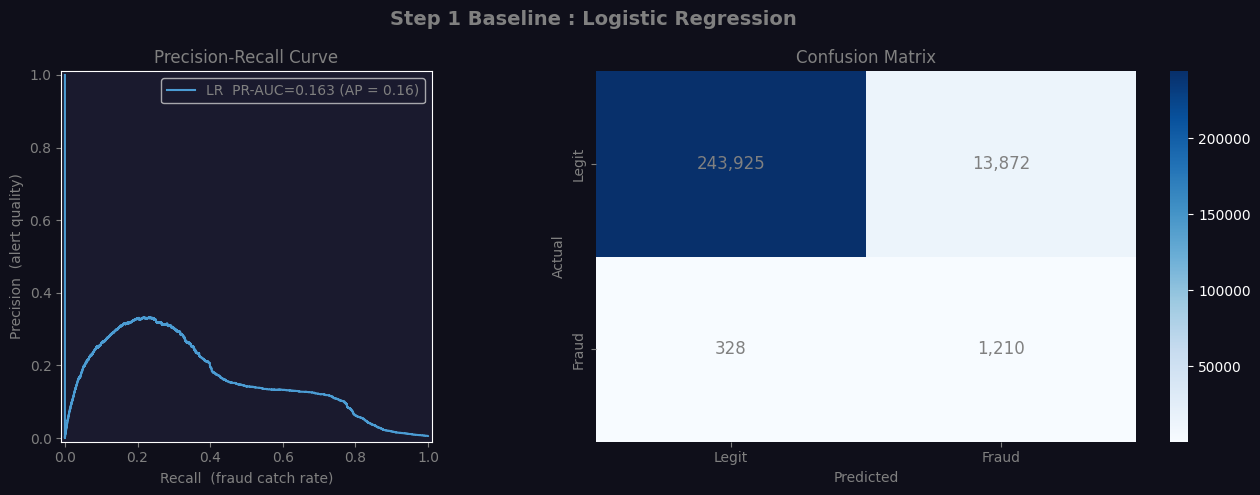


 PR-AUC to beat on Step 2: 0.1625


In [12]:
# ─────────────────────────────────────────────────────────────
# Step 1: Evaluation Plots
# ─────────────────────────────────────────────────────────────
# In this cell, I visualize the performance of the baseline Logistic Regression model.
#
# Instead of looking only at printed metrics, I create two plots:
#   1) Precision-Recall Curve
#   2) Confusion Matrix
#
# These plots help me understand how well the model handles the fraud class and give me a visual baseline to compare against stronger models later.

# Create a figure with 2 side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f0f1a')

# Add a title for the full figure
fig.suptitle(
    'Step 1 Baseline : Logistic Regression',
    fontsize=14,
    fontweight='bold',
    color='gray'
)


# ─────────────────────────────────────────────────────────────
# Left Plot | Precision-Recall Curve
# ─────────────────────────────────────────────────────────────
# This chart shows the trade-off between:
#   - Recall    → how many fraud cases the model catches
#   - Precision → how many flagged fraud alerts are actually fraud
#
# This is especially important for fraud detection because the dataset is highly imbalanced, so PR-AUC is more meaningful than accuracy.

ax = axes[0]
ax.set_facecolor('#1a1a2e')

PrecisionRecallDisplay.from_predictions(
    y_test,          # true labels from the test set
    y_prob_lr,       # predicted fraud probabilities from Logistic Regression
    ax=ax,
    name=f'LR  PR-AUC={pr_auc_lr:.3f}',
    color=PALETTE['legit']
)

ax.set_title('Precision-Recall Curve', color='gray')
ax.set_xlabel('Recall  (fraud catch rate)', color='gray')
ax.set_ylabel('Precision  (alert quality)', color='gray')
ax.tick_params(colors='gray')
ax.legend(facecolor='#1a1a2e', labelcolor='gray')


# ─────────────────────────────────────────────────────────────
# Right Plot | Confusion Matrix
# ─────────────────────────────────────────────────────────────
# The confusion matrix shows how many predictions were:
#   - True Legit
#   - False Fraud Alert
#   - Missed Fraud
#   - Correctly Detected Fraud
#
# This makes it easier to see the real behavior of the model.

ax = axes[1]
ax.set_facecolor('#1a1a2e')

# Build confusion matrix from true labels and predicted classes
cm = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt=',',
    cmap='Blues',
    ax=ax,
    xticklabels=['Legit', 'Fraud'],
    yticklabels=['Legit', 'Fraud'],
    annot_kws={'size': 12, 'color': 'gray'}
)

ax.set_title('Confusion Matrix', color='gray')
ax.set_xlabel('Predicted', color='gray')
ax.set_ylabel('Actual', color='gray')
ax.tick_params(colors='gray')


# ─────────────────────────────────────────────────────────────
# Save and show the figure
# ─────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig(
    REPORTS_DIR / 'step1_baseline_logreg.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

# Print the baseline PR-AUC so I remember the score that the next models need to beat.
print(f'\n PR-AUC to beat on Step 2: {pr_auc_lr:.4f}')

The Logistic Regression baseline correctly detected **1,210 fraud transactions** out of **1,538 total fraud cases** in the test set. This means the model caught most fraud cases, with a fraud recall of about **79%**.

However, the model also incorrectly flagged **13,872 legitimate transactions** as fraud. This explains why the fraud precision is low. The model is sensitive to fraud, but it still creates many false alerts.

The Precision-Recall Curve shows the trade-off between catching fraud and keeping alerts accurate. The baseline PR-AUC is **0.1625**, which will be used as the score that the next models should try to beat.
